# EDA y auditoria de calidad de datos — SBA National Loans

**Proyecto:** scoring de credito para pymes (SBA "Should This Loan Be Approved or Denied?")

**Objetivo de este notebook (Fase 1):** auditar la calidad del dataset crudo,
documentar y corregir cada problema detectado, y explorar el comportamiento
del target (impago) frente a las variables disponibles en el momento de la
originacion del prestamo. No se entrena ningun modelo en esta fase.

El dataset cubre ~899k prestamos concedidos por la SBA (Small Business
Administration) entre 1962 y 2014, con informacion de si el prestamo fue
pagado en su totalidad (`P I F`) o entro en impago (`CHGOFF`).


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Permite importar `src` tanto si el notebook se ejecuta desde notebooks/
# como si se ejecuta desde la raiz del repo.
REPO_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from src.data_cleaning import load_and_clean, LEAKAGE_COLS, ID_COLS, NAICS_SECTOR_MAP

RANDOM_STATE = 42
RAW_PATH = REPO_ROOT / "data" / "raw" / "SBAnational.csv"
PROCESSED_PATH = REPO_ROOT / "data" / "processed" / "sba_clean.parquet"
FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True, parents=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


## 1. Carga del dataset crudo

Cargamos el CSV sin limpiar (`low_memory=False` porque el fichero pesa
~180 MB y tiene columnas con tipos mixtos) para documentar el estado
"antes" de cada problema de calidad antes de aplicar `load_and_clean`.


In [2]:
df_raw = pd.read_csv(RAW_PATH, low_memory=False)
print(f"Dimensiones: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
df_raw.head()


Dimensiones: 899,164 filas x 27 columnas


,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,84,4,2.0,0,0,1,0,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,60,2,2.0,0,0,1,0,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,180,7,1.0,0,0,1,0,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,60,2,1.0,0,0,1,0,N,Y,NaN,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,240,14,1.0,7,7,1,0,N,N,NaN,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


In [3]:
df_raw.dtypes


LoanNr_ChkDgt          int64
Name                  object
City                  object
State                 object
Zip                    int64
Bank                  object
BankState             object
NAICS                  int64
ApprovalDate          object
ApprovalFY            object
Term                   int64
NoEmp                  int64
NewExist             float64
CreateJob              int64
RetainedJob            int64
FranchiseCode          int64
UrbanRural             int64
RevLineCr             object
LowDoc                object
ChgOffDate            object
DisbursementDate      object
DisbursementGross     object
BalanceGross          object
MIS_Status            object
ChgOffPrinGr          object
GrAppv                object
SBA_Appv              object
dtype: object

## 2. Resumen general: nulos, tipos y duplicados

Antes de entrar en el detalle de cada columna, revisamos la salud general
del dataset.


In [4]:
nulls = df_raw.isna().sum()
nulls_pct = (nulls / len(df_raw) * 100).round(2)
resumen_nulos = pd.DataFrame({"n_nulos": nulls, "pct_nulos": nulls_pct})
resumen_nulos = resumen_nulos[resumen_nulos["n_nulos"] > 0].sort_values("n_nulos", ascending=False)
resumen_nulos


,n_nulos,pct_nulos
ChgOffDate,736465,81.91
RevLineCr,4528,0.50
LowDoc,2582,0.29
DisbursementDate,2368,0.26
MIS_Status,1997,0.22
BankState,1566,0.17
Bank,1559,0.17
NewExist,136,0.02
City,30,0.00
State,14,0.00


In [5]:
# LoanNr_ChkDgt deberia ser un identificador unico por prestamo
n_dup = df_raw["LoanNr_ChkDgt"].duplicated().sum()
print(f"Filas totales: {len(df_raw):,}")
print(f"LoanNr_ChkDgt duplicados: {n_dup}")
assert n_dup == 0, "Se esperaba que LoanNr_ChkDgt fuera unico"
print("OK: LoanNr_ChkDgt es unico para cada prestamo.")


Filas totales: 899,164
LoanNr_ChkDgt duplicados: 0
OK: LoanNr_ChkDgt es unico para cada prestamo.


## 3. Auditoria de calidad de datos

Recorremos, uno a uno, los problemas de calidad detectados en el dataset,
mostrando el estado "antes" (dataset crudo) y explicando la transformacion
que aplica `load_and_clean` (definida en `src/data_cleaning.py`) para
corregirlo. El "despues" se valida mas adelante, una vez cargado el
dataset limpio completo.


### 3.1 Target: `MIS_Status`

El target viene como texto con dos categorias (`"P I F"` = pagado en su
totalidad, `"CHGOFF"` = impago/charge-off) y ademas tiene valores nulos:
filas en las que no se registro el estado final del prestamo. Estas filas
no aportan senal para un problema de clasificacion binaria y se eliminan.

**Decision:** `target = 1` si `MIS_Status == "CHGOFF"`, `target = 0` si
`MIS_Status == "P I F"`; se eliminan las filas con `MIS_Status` nulo.


In [6]:
print("--- Antes (crudo) ---")
print(df_raw["MIS_Status"].value_counts(dropna=False))

n_nulos_target = df_raw["MIS_Status"].isna().sum()
print(f"\nFilas con MIS_Status nulo a eliminar: {n_nulos_target:,} "
      f"({n_nulos_target / len(df_raw) * 100:.2f}% del dataset)")


--- Antes (crudo) ---
MIS_Status
P I F     739609
CHGOFF    157558
NaN         1997
Name: count, dtype: int64

Filas con MIS_Status nulo a eliminar: 1,997 (0.22% del dataset)


### 3.2 Columnas monetarias almacenadas como texto

`DisbursementGross`, `BalanceGross`, `ChgOffPrinGr`, `GrAppv` y `SBA_Appv`
vienen como strings con simbolo de moneda, separador de miles y espacios
finales (p.ej. `"$60,000.00 "`). Se parsean a `float` quitando `$`, `,` y
espacios.


In [7]:
money_cols = ["DisbursementGross", "BalanceGross", "ChgOffPrinGr", "GrAppv", "SBA_Appv"]
print("--- Antes (crudo) ---")
for c in money_cols:
    print(f"{c}: dtype={df_raw[c].dtype}, ejemplo={df_raw[c].dropna().iloc[0]!r}")


--- Antes (crudo) ---
DisbursementGross: dtype=object, ejemplo='$60,000.00 '
BalanceGross: dtype=object, ejemplo='$0.00 '


ChgOffPrinGr: dtype=object, ejemplo='$0.00 '


GrAppv: dtype=object, ejemplo='$60,000.00 '


SBA_Appv: dtype=object, ejemplo='$48,000.00 '


### 3.3 `ApprovalFY`: tipos mixtos

`ApprovalFY` deberia ser un ano (entero), pero contiene al menos un valor
con sufijo no numerico: `"1976A"`. Se extraen los digitos y se convierte a
entero.


In [8]:
fy_bad = df_raw["ApprovalFY"].astype(str)
mask_no_numerico = ~fy_bad.str.match(r"^\d+$")
print("--- Valores no puramente numericos en ApprovalFY (antes) ---")
print(fy_bad[mask_no_numerico].value_counts())


--- Valores no puramente numericos en ApprovalFY (antes) ---
ApprovalFY
1976A    18
Name: count, dtype: int64


### 3.4 `RevLineCr`: solo Y/N son validos

Ademas de `Y`/`N`, la columna contiene `"0"` (257k filas), `"T"` (15k) y un
resto de valores residuales (`` ` ``, `1`, `2`, `R`, `C`, etc.). Dado el
volumen de filas afectadas (no son unos pocos residuos, son cientos de
miles), **no se eliminan filas**: todo lo que no sea `Y`/`N` se mapea a
`"Unknown"`, una categoria propia que el modelo podra aprender a tratar.


In [9]:
print("--- Antes (crudo) ---")
print(df_raw["RevLineCr"].value_counts(dropna=False))


--- Antes (crudo) ---
RevLineCr
N      420288
0      257602
Y      201397
T       15284
NaN      4528
1          23
R          14
`          11
2           6
C           2
,           1
3           1
7           1
A           1
5           1
.           1
4           1
-           1
Q           1
Name: count, dtype: int64


### 3.5 `LowDoc`: mismo patron que `RevLineCr`

Solo `Y`/`N` son validos; `0`, `C`, `S`, `A`, `R` son residuos que se
mapean a `"Unknown"` por el mismo motivo que en `RevLineCr`.


In [10]:
print("--- Antes (crudo) ---")
print(df_raw["LowDoc"].value_counts(dropna=False))


--- Antes (crudo) ---
LowDoc
N      782822
Y      110335
NaN      2582
0        1491
C         758
S         603
A         497
R          75
1           1
Name: count, dtype: int64


### 3.6 `NewExist`: ceros y nulos

`1` = negocio existente, `2` = negocio nuevo. Hay 1.034 filas con `0`
(valor no documentado) y 136 nulos. Se mapean ambos casos a `"Unknown"` en
la columna derivada `new_exist_label`.


In [11]:
print("--- Antes (crudo) ---")
print(df_raw["NewExist"].value_counts(dropna=False))


--- Antes (crudo) ---
NewExist
1.0    644869
2.0    253125
0.0      1034
NaN       136
Name: count, dtype: int64


### 3.7 `NAICS`: 201.948 filas con sector desconocido (`0`)

El codigo NAICS identifica el sector economico del negocio. Los 2 primeros
digitos determinan el sector segun la tabla oficial NAICS. Un valor `0`
significa sector no informado. Se crea la columna derivada `sector`
mapeando los 2 primeros digitos a su nombre de sector; `0` -> `"Unknown"`.


In [12]:
naics_zero = (df_raw["NAICS"] == 0).sum()
print(f"Filas con NAICS == 0: {naics_zero:,} ({naics_zero / len(df_raw) * 100:.1f}%)")
print()
print("Tabla NAICS de 2 digitos usada para el mapeo:")
for code_, sector in NAICS_SECTOR_MAP.items():
    print(f"  {code_}: {sector}")


Filas con NAICS == 0: 201,948 (22.5%)

Tabla NAICS de 2 digitos usada para el mapeo:
  11: Agriculture, Forestry, Fishing and Hunting
  21: Mining, Quarrying, and Oil and Gas Extraction
  22: Utilities
  23: Construction
  31: Manufacturing
  32: Manufacturing
  33: Manufacturing
  42: Wholesale Trade
  44: Retail Trade
  45: Retail Trade
  48: Transportation and Warehousing
  49: Transportation and Warehousing
  51: Information
  52: Finance and Insurance
  53: Real Estate and Rental and Leasing
  54: Professional, Scientific, and Technical Services
  55: Management of Companies and Enterprises
  56: Administrative and Support and Waste Management Services
  61: Educational Services
  62: Health Care and Social Assistance
  71: Arts, Entertainment, and Recreation
  72: Accommodation and Food Services
  81: Other Services (except Public Administration)
  92: Public Administration


### 3.8 Fechas: formato `28-Feb-99` y el riesgo del ano a 2 digitos

`ApprovalDate`, `DisbursementDate` y `ChgOffDate` vienen en formato
`DD-Mon-YY`. El riesgo es interpretar mal el ano a 2 digitos: por defecto,
muchas herramientas (incluido el pivote por defecto de `strptime`,
00-68 -> 20xx / 69-99 -> 19xx) mapearian `"62"` a `2062`, cuando en
realidad el dataset cubre 1962-2014 y `"62"` debe ser `1962`.

Comprobamos que los sufijos de 2 digitos presentes en el dataset solo
ocupan los rangos `00-14` y `61-99` (no hay ningun valor entre 15 y 60),
lo que permite un pivote inequivoco: `00-14` -> `2000-2014`,
`15-99` -> `1915-1999`. `load_and_clean` (funcion `_parse_sba_date`)
implementa este pivote y ademas valida que ninguna fecha resultante sea
posterior a 2014 (lanza `ValueError` si lo fuera).


In [13]:
sufijos = df_raw["ApprovalDate"].dropna().astype(str).str.extract(r"-(\d{2})$")[0].astype(int)
print("Sufijos de ano de 2 digitos presentes en ApprovalDate:")
print(sorted(sufijos.unique()))


Sufijos de ano de 2 digitos presentes en ApprovalDate:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(61), np.int64(64), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79), np.int64(80), np.int64(81), np.int64(82), np.int64(83), np.int64(84), np.int64(85), np.int64(86), np.int64(87), np.int64(88), np.int64(89), np.int64(90), np.int64(91), np.int64(92), np.int64(93), np.int64(94), np.int64(95), np.int64(96), np.int64(97), np.int64(98), np.int64(99)]


### 3.9 Inconsistencia entre `MIS_Status` y `ChgOffDate`

Cabria esperar que `ChgOffDate` (fecha de charge-off) estuviera informada
si y solo si `MIS_Status == "CHGOFF"`. No es exactamente asi:


In [14]:
n_chgoffdate = df_raw["ChgOffDate"].notna().sum()
n_mis_chgoff = (df_raw["MIS_Status"] == "CHGOFF").sum()
overlap = ((df_raw["MIS_Status"] == "CHGOFF") & df_raw["ChgOffDate"].notna()).sum()
solo_fecha = (df_raw["ChgOffDate"].notna() & (df_raw["MIS_Status"] != "CHGOFF")).sum()
solo_status = ((df_raw["MIS_Status"] == "CHGOFF") & df_raw["ChgOffDate"].isna()).sum()

print(f"ChgOffDate no nula:                          {n_chgoffdate:,}")
print(f"MIS_Status == CHGOFF:                        {n_mis_chgoff:,}")
print(f"Solape (ambas condiciones a la vez):         {overlap:,}")
print(f"ChgOffDate no nula pero MIS_Status != CHGOFF: {solo_fecha:,}")
print(f"MIS_Status == CHGOFF pero ChgOffDate nula:    {solo_status:,}")


ChgOffDate no nula:                          162,699
MIS_Status == CHGOFF:                        157,558
Solape (ambas condiciones a la vez):         157,511
ChgOffDate no nula pero MIS_Status != CHGOFF: 5,188
MIS_Status == CHGOFF pero ChgOffDate nula:    47


**Decision:** la inconsistencia afecta a ~5.2k filas con `ChgOffDate`
informada pero `MIS_Status` distinto de `CHGOFF` (posibles prestamos
reinstaurados tras un charge-off, o errores de captura), y 47 filas con
`MIS_Status == CHGOFF` sin fecha de charge-off. Dado que `MIS_Status` es
el campo disenado explicitamente para reportar el estado final del
prestamo (mientras que `ChgOffDate` es un campo operativo/administrativo
que puede quedar desactualizado), **se mantiene `MIS_Status` como fuente
de verdad para el target** y la inconsistencia queda documentada aqui para
que se tenga en cuenta en el analisis temporal de la Fase 3.


### 3.10 Valores sospechosos: `Term == 0` y `NoEmp == 0`


In [15]:
term_zero = (df_raw["Term"] == 0).sum()
noemp_zero = (df_raw["NoEmp"] == 0).sum()
print(f"Term == 0:  {term_zero:,} filas ({term_zero / len(df_raw) * 100:.2f}%)")
print(f"NoEmp == 0: {noemp_zero:,} filas ({noemp_zero / len(df_raw) * 100:.2f}%)")

print()
print("Tasa de impago cuando Term == 0 vs resto:")
print(df_raw.assign(chgoff=(df_raw["MIS_Status"] == "CHGOFF").astype(int))
      .groupby(df_raw["Term"] == 0)["chgoff"].mean())

print()
print("Tasa de impago cuando NoEmp == 0 vs resto:")
print(df_raw.assign(chgoff=(df_raw["MIS_Status"] == "CHGOFF").astype(int))
      .groupby(df_raw["NoEmp"] == 0)["chgoff"].mean())


Term == 0:  810 filas (0.09%)
NoEmp == 0: 6,631 filas (0.74%)

Tasa de impago cuando Term == 0 vs resto:


Term
False    0.174568
True     0.906173
Name: chgoff, dtype: float64

Tasa de impago cuando NoEmp == 0 vs resto:


NoEmp
False    0.174778
True     0.235711
Name: chgoff, dtype: float64


**Decision:** ambos casos tienen una tasa de impago claramente distinta
del resto de la poblacion (se comprueba arriba), lo que sugiere que **no
son errores aleatorios sino subpoblaciones con comportamiento propio**
(`Term == 0` podria corresponder a lineas de credito o prestamos
liquidados/anotados de forma atipica; `NoEmp == 0` es coherente con
autonomos o negocios unipersonales sin empleados declarados). Eliminar
estas filas descartaria senal real y reduciria el dataset sin necesidad.
**No se eliminan filas**: `load_and_clean` anade los flags booleanos
`flag_term_zero` y `flag_noemp_zero` para que puedan tratarse de forma
explicita (como feature o como criterio de segmentacion) en la Fase 2.


### 3.11 `FranchiseCode`: negocio franquiciado

`0` o `1` significan que el negocio **no** es una franquicia; cualquier
valor mayor indica el codigo de una franquicia concreta. Se crea la
binaria `is_franchise`.


In [16]:
print(df_raw["FranchiseCode"].value_counts().head(10))
print()
print(f"Valores <= 1 (no franquicia): {(df_raw['FranchiseCode'] <= 1).sum():,}")
print(f"Valores > 1 (franquicia):     {(df_raw['FranchiseCode'] > 1).sum():,}")


FranchiseCode
1        638554
0        208835
78760      3373
68020      1921
50564      1034
21780      1003
25650       715
79140       659
22470       615
17998       606
Name: count, dtype: int64

Valores <= 1 (no franquicia): 847,389
Valores > 1 (franquicia):     51,775


### 3.12 `UrbanRural`: codificacion numerica

`0` = indefinido, `1` = urbano, `2` = rural. Se crea `urban_rural_label`
con las etiquetas legibles.


In [17]:
print(df_raw["UrbanRural"].value_counts(dropna=False))


UrbanRural
1    470654
0    323167
2    105343
Name: count, dtype: int64


## 4. Aplicar `load_and_clean` y validar el resultado

Con todos los problemas documentados, aplicamos la funcion de limpieza
completa (que reutilizaremos en las fases 2 y 3) y verificamos que el
"despues" de cada columna es el esperado.


In [18]:
df = load_and_clean(str(RAW_PATH))
print(f"Dimensiones tras limpieza: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Filas eliminadas (MIS_Status nulo): {len(df_raw) - len(df):,}")


Dimensiones tras limpieza: 897,167 filas x 36 columnas
Filas eliminadas (MIS_Status nulo): 1,997


In [19]:
print("--- Despues: target ---")
print(df["target"].value_counts(dropna=False))
print(f"Tasa de impago global: {df['target'].mean() * 100:.2f}%")


--- Despues: target ---
target
0    739609
1    157558
Name: count, dtype: int64
Tasa de impago global: 17.56%


In [20]:
print("--- Despues: columnas monetarias (dtype) ---")
print(df[money_cols].dtypes)
df[money_cols].describe()


--- Despues: columnas monetarias (dtype) ---
DisbursementGross    float64
BalanceGross         float64
ChgOffPrinGr         float64
GrAppv               float64
SBA_Appv             float64
dtype: object


,DisbursementGross,BalanceGross,ChgOffPrinGr,GrAppv,SBA_Appv
count,8.971670e+05,897167.000000,8.971670e+05,8.971670e+05,8.971670e+05
mean,2.015980e+05,2.996003,1.352721e+04,1.930595e+05,1.497807e+05
std,2.878066e+05,1443.766066,6.520986e+04,2.834331e+05,2.285600e+05
min,4.000000e+03,0.000000,0.000000e+00,1.000000e+03,5.000000e+02
25%,4.249200e+04,0.000000,0.000000e+00,3.500000e+04,2.125000e+04
50%,1.000000e+05,0.000000,0.000000e+00,9.000000e+04,6.205000e+04
75%,2.390000e+05,0.000000,0.000000e+00,2.250000e+05,1.750000e+05
max,1.144632e+07,996262.000000,3.512596e+06,5.472000e+06,5.472000e+06


In [21]:
print("--- Despues: ApprovalFY ---")
print(df["ApprovalFY"].dtype)
print(f"Rango: {df['ApprovalFY'].min()} - {df['ApprovalFY'].max()}")


--- Despues: ApprovalFY ---
Int64
Rango: 1966 - 2014


In [22]:
print("--- Despues: RevLineCr / LowDoc ---")
print(df["RevLineCr"].value_counts())
print()
print(df["LowDoc"].value_counts())


--- Despues: RevLineCr / LowDoc ---
RevLineCr
N          419252
Unknown    277255
Y          200660
Name: count, dtype: int64

LowDoc
N          780997
Y          110171
Unknown      5999
Name: count, dtype: int64


In [23]:
print("--- Despues: new_exist_label / urban_rural_label / sector ---")
print(df["new_exist_label"].value_counts())
print()
print(df["urban_rural_label"].value_counts())
print()
print(df["sector"].value_counts())


--- Despues: new_exist_label / urban_rural_label / sector ---
new_exist_label
Existing    643446
New         252559
Unknown       1162
Name: count, dtype: int64

urban_rural_label
Urban      469281
Unknown    322826
Rural      105060
Name: count, dtype: int64



sector
Unknown                                                     201667
Retail Trade                                                126975
Other Services (except Public Administration)                72395
Professional, Scientific, and Technical Services             67922
Manufacturing                                                67903
Accommodation and Food Services                              67511
Construction                                                 66492
Health Care and Social Assistance                            55264
Wholesale Trade                                              48673
Administrative and Support and Waste Management Services     32529
Transportation and Warehousing                               22408
Arts, Entertainment, and Recreation                          14616
Real Estate and Rental and Leasing                           13588
Information                                                  11362
Finance and Insurance                                  

In [24]:
print("--- Despues: fechas parseadas ---")
date_cols = ["ApprovalDate", "DisbursementDate", "ChgOffDate"]
print(df[date_cols].dtypes)
print()
for c in date_cols:
    print(f"{c}: min={df[c].min()}, max={df[c].max()}")

max_valid = pd.Timestamp("2014-12-31")
n_futuras = sum((df[c] > max_valid).sum() for c in date_cols)
print(f"\nFechas posteriores a 2014 (deberia ser 0): {n_futuras}")


--- Despues: fechas parseadas ---
ApprovalDate        datetime64[ns]
DisbursementDate    datetime64[ns]
ChgOffDate          datetime64[ns]
dtype: object

ApprovalDate: min=1966-05-18 00:00:00, max=2014-06-25 00:00:00


DisbursementDate: min=1920-04-14 00:00:00, max=2014-12-31 00:00:00
ChgOffDate: min=1926-10-22 00:00:00, max=2014-08-29 00:00:00

Fechas posteriores a 2014 (deberia ser 0): 0


In [25]:
print("--- Despues: is_franchise, flags ---")
print(df["is_franchise"].value_counts())
print()
print(f"flag_term_zero:  {df['flag_term_zero'].sum():,}")
print(f"flag_noemp_zero: {df['flag_noemp_zero'].sum():,}")


--- Despues: is_franchise, flags ---
is_franchise
0    845435
1     51732
Name: count, dtype: int64

flag_term_zero:  806
flag_noemp_zero: 6,621


In [26]:
print("--- sba_guarantee_pct ---")
df["sba_guarantee_pct"].describe()


--- sba_guarantee_pct ---


count    897167.000000
mean          0.709698
std           0.173714
min           0.028140
25%           0.500000
50%           0.750000
75%           0.850000
max           1.000000
Name: sba_guarantee_pct, dtype: float64

## 5. Variables disponibles en originacion

Antes de pasar al analisis del target, clasificamos cada columna del
dataset limpio segun si estara disponible en el momento de conceder el
prestamo (por tanto usable como feature del modelo de originacion), si es
un identificador sin valor predictivo, o si constituye **leakage**
(informacion conocida solo despues de la concesion, que un modelo de
originacion nunca deberia poder ver).

`LEAKAGE_COLS` e `ID_COLS`, definidas en `src/data_cleaning.py`, encapsulan
esta clasificacion para poder excluirlas facilmente al construir la matriz
de features en la Fase 2. `load_and_clean` las conserva en el DataFrame
porque `ChgOffDate`/`ChgOffPrinGr`/`BalanceGross`/`MIS_Status` haran falta
para el analisis temporal (PSI, estabilidad del Gini) de la Fase 3.


In [27]:
clasificacion = {
    "LoanNr_ChkDgt": "identificador",
    "Name": "identificador",
    "City": "feature valida (alta cardinalidad, revisar en Fase 2)",
    "State": "feature valida",
    "Zip": "feature valida (alta cardinalidad, revisar en Fase 2)",
    "Bank": "feature valida (alta cardinalidad, revisar en Fase 2)",
    "BankState": "feature valida",
    "NAICS": "feature valida (usar `sector`)",
    "ApprovalDate": "feature valida (usar para `approval_year` / cohortes)",
    "ApprovalFY": "feature valida",
    "Term": "feature valida",
    "NoEmp": "feature valida",
    "NewExist": "feature valida (usar `new_exist_label`)",
    "CreateJob": "feature valida",
    "RetainedJob": "feature valida",
    "FranchiseCode": "feature valida (usar `is_franchise`)",
    "UrbanRural": "feature valida (usar `urban_rural_label`)",
    "RevLineCr": "feature valida",
    "LowDoc": "feature valida",
    "ChgOffDate": "LEAKAGE (fecha de impago, posterior a la originacion)",
    "DisbursementDate": "LEAKAGE (puede ser muy posterior a la aprobacion)",
    "DisbursementGross": "LEAKAGE (importe efectivamente desembolsado, puede diferir del aprobado y conocerse tarde)",
    "BalanceGross": "LEAKAGE (saldo vivo, se actualiza durante la vida del prestamo)",
    "MIS_Status": "TARGET / LEAKAGE (es el origen del target, nunca como feature)",
    "ChgOffPrinGr": "LEAKAGE (importe en impago)",
    "GrAppv": "feature valida (importe aprobado, conocido en originacion)",
    "SBA_Appv": "feature valida (importe garantizado por la SBA, conocido en originacion)",
    "sba_guarantee_pct": "feature valida (derivada de GrAppv/SBA_Appv)",
    "approval_year": "feature valida / clave de cohorte temporal",
    "sector": "feature valida",
    "new_exist_label": "feature valida",
    "urban_rural_label": "feature valida",
    "is_franchise": "feature valida",
    "flag_term_zero": "feature valida (trazabilidad)",
    "flag_noemp_zero": "feature valida (trazabilidad)",
}
tabla_clasificacion = pd.DataFrame.from_dict(clasificacion, orient="index", columns=["clasificacion"])
tabla_clasificacion.index.name = "columna"
tabla_clasificacion


,clasificacion
columna,
LoanNr_ChkDgt,identificador
Name,identificador
City,"feature valida (alta cardinalidad, revisar en ..."
State,feature valida
Zip,"feature valida (alta cardinalidad, revisar en ..."
Bank,"feature valida (alta cardinalidad, revisar en ..."
BankState,feature valida
NAICS,feature valida (usar `sector`)
ApprovalDate,feature valida (usar para `approval_year` / co...


In [28]:
print("LEAKAGE_COLS:", LEAKAGE_COLS)
print("ID_COLS:", ID_COLS)


LEAKAGE_COLS: ['ChgOffDate', 'ChgOffPrinGr', 'BalanceGross', 'MIS_Status', 'DisbursementDate', 'DisbursementGross']
ID_COLS: ['LoanNr_ChkDgt', 'Name']


## 6. Guardar el dataset limpio

Guardamos el resultado en `data/processed/sba_clean.parquet` para que las
fases 2 y 3 puedan partir de el sin repetir la limpieza.


In [29]:
PROCESSED_PATH.parent.mkdir(exist_ok=True, parents=True)
df.to_parquet(PROCESSED_PATH, index=False)
print(f"Guardado en {PROCESSED_PATH} ({PROCESSED_PATH.stat().st_size / 1e6:.1f} MB)")


Guardado en C:\Users\EliteBook\Desktop\Proyectos_CV\sme-credit-scoring\data\processed\sba_clean.parquet (45.6 MB)


## 7. Analisis del target

### 7.1 Tasa de impago global y evolucion por cohorte de aprobacion

Usamos `approval_year` (derivado de `ApprovalDate`) como cohorte temporal.
Se espera un pico claro en las cohortes 2005-2008, coincidiendo con la
crisis financiera de 2008: los prestamos concedidos en esos anos tuvieron
mas tiempo y peores condiciones macro para entrar en impago.


**Aviso de lectura**: las cohortes muy antiguas (1966-1988) tienen muy
pocos prestamos (decenas, no miles) y una tasa de impago cercana al 100%
que NO debe interpretarse como una senal economica — es un artefacto de
muestra pequena combinado con la ventana de observacion completa (esos
prestamos tuvieron decadas para hacer default o pagarse). De forma
simetrica, las cohortes mas recientes (2012-2014) muestran tasas de
impago artificialmente bajas porque, al cierre del dataset (2014), la
mayoria de esos prestamos todavia no ha tenido tiempo de madurar y entrar
en impago (censura por la derecha). El rango fiable para leer el ciclo
economico es aproximadamente 1989-2011, donde el volumen de prestamos por
cohorte ya es representativo (miles de prestamos/ano).

In [30]:
tasa_global = df["target"].mean()
print(f"Tasa de impago global: {tasa_global * 100:.2f}%")

tasa_por_anio = df.groupby("approval_year")["target"].agg(["mean", "count"])
tasa_por_anio.columns = ["tasa_impago", "n_prestamos"]
tasa_por_anio


Tasa de impago global: 17.56%


,tasa_impago,n_prestamos
approval_year,,
1966,1.000000,1
1968,1.000000,3
1969,0.666667,3
1970,0.944444,18
1971,0.857143,14
1972,0.860465,43
1973,0.977273,44
1974,0.906250,32
1975,0.979167,48


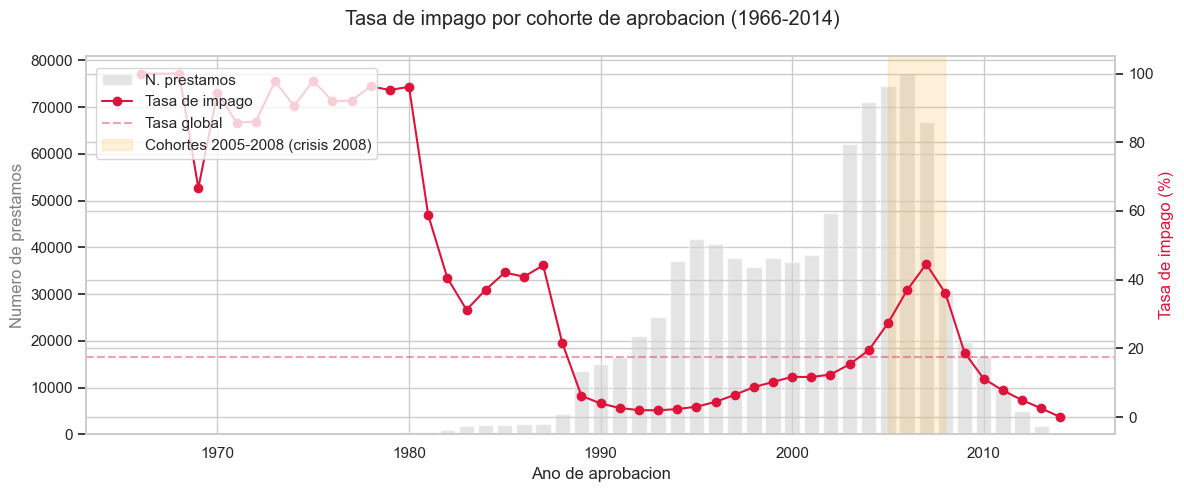

In [31]:
fig, ax1 = plt.subplots(figsize=(12, 5))

anios = tasa_por_anio.index
ax1.bar(anios, tasa_por_anio["n_prestamos"], color="lightgray", alpha=0.6, label="N. prestamos")
ax1.set_ylabel("Numero de prestamos", color="gray")
ax1.set_xlabel("Ano de aprobacion")

ax2 = ax1.twinx()
ax2.plot(anios, tasa_por_anio["tasa_impago"] * 100, color="crimson", marker="o", label="Tasa de impago")
ax2.axhline(tasa_global * 100, color="crimson", linestyle="--", alpha=0.4, label="Tasa global")
ax2.axvspan(2005, 2008, color="orange", alpha=0.15, label="Cohortes 2005-2008 (crisis 2008)")
ax2.set_ylabel("Tasa de impago (%)", color="crimson")

fig.suptitle("Tasa de impago por cohorte de aprobacion (1966-2014)")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.88))
fig.tight_layout()
fig.savefig(FIGURES_DIR / "target_by_approval_year.png", dpi=150)
plt.show()


### 7.2 Tasa de impago por sector


In [32]:
tasa_sector = df.groupby("sector")["target"].agg(["mean", "count"]).sort_values("mean", ascending=False)
tasa_sector.columns = ["tasa_impago", "n_prestamos"]
tasa_sector


,tasa_impago,n_prestamos
sector,,
Real Estate and Rental and Leasing,0.287312,13588
Finance and Insurance,0.284266,9470
Transportation and Warehousing,0.265039,22408
Information,0.248284,11362
Educational Services,0.242462,6401
Administrative and Support and Waste Management Services,0.235513,32529
Construction,0.232554,66492
Retail Trade,0.227352,126975
Accommodation and Food Services,0.220438,67511


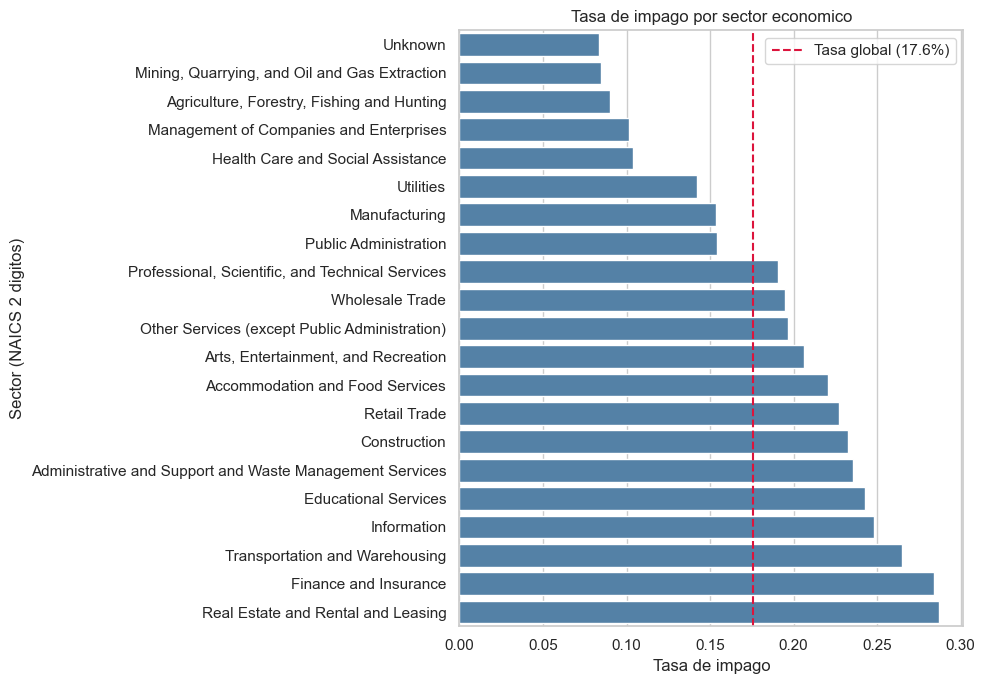

In [33]:
fig, ax = plt.subplots(figsize=(10, 7))
orden = tasa_sector.sort_values("tasa_impago").index
sns.barplot(data=df, y="sector", x="target", order=orden, estimator="mean", errorbar=None, ax=ax, color="steelblue")
ax.axvline(tasa_global, color="crimson", linestyle="--", label=f"Tasa global ({tasa_global * 100:.1f}%)")
ax.set_xlabel("Tasa de impago")
ax.set_ylabel("Sector (NAICS 2 digitos)")
ax.set_title("Tasa de impago por sector economico")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "default_rate_by_sector.png", dpi=150)
plt.show()


### 7.3 Tasa de impago por estado (top / bottom 10)

Para evitar que estados con muy pocos prestamos distorsionen el ranking,
filtramos a estados con al menos 500 prestamos.


In [34]:
tasa_estado = df.groupby("State")["target"].agg(["mean", "count"])
tasa_estado.columns = ["tasa_impago", "n_prestamos"]
tasa_estado = tasa_estado[tasa_estado["n_prestamos"] >= 500]

top10 = tasa_estado.sort_values("tasa_impago", ascending=False).head(10)
bottom10 = tasa_estado.sort_values("tasa_impago", ascending=True).head(10)

print("--- Top 10 estados con mayor tasa de impago (n >= 500) ---")
print(top10)
print()
print("--- Bottom 10 estados con menor tasa de impago (n >= 500) ---")
print(bottom10)


--- Top 10 estados con mayor tasa de impago (n >= 500) ---
       tasa_impago  n_prestamos
State                          
FL        0.273694        41192
DC        0.239926         1613
GA        0.239628        22272
NV        0.232236         8022
IL        0.226701        29594
MI        0.225052        20493
TN        0.212128         9400
AZ        0.207501        17624
SC        0.204647         5595
NJ        0.201125        24010

--- Bottom 10 estados con menor tasa de impago (n >= 500) ---
       tasa_impago  n_prestamos
State                          
MT        0.067987         8737
WY        0.070120         2838
VT        0.074360         5433
ND        0.076762         5237
SD        0.078817         4428
ME        0.098198         5937
NH        0.107211        12023
NM        0.109193         6026
RI        0.113545         8948
NE        0.113775         6381


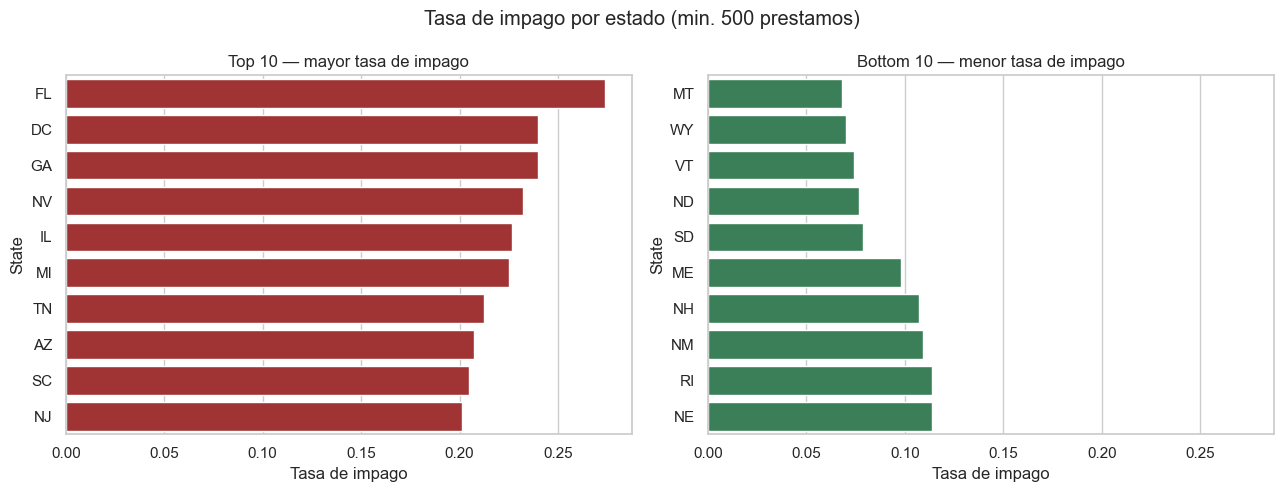

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
sns.barplot(x=top10["tasa_impago"], y=top10.index, ax=axes[0], color="firebrick")
axes[0].set_title("Top 10 — mayor tasa de impago")
axes[0].set_xlabel("Tasa de impago")

sns.barplot(x=bottom10["tasa_impago"], y=bottom10.index, ax=axes[1], color="seagreen")
axes[1].set_title("Bottom 10 — menor tasa de impago")
axes[1].set_xlabel("Tasa de impago")

fig.suptitle("Tasa de impago por estado (min. 500 prestamos)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "default_rate_by_state.png", dpi=150)
plt.show()


### 7.4 Tasa de impago por plazo del prestamo (`Term`, bucketizado)


In [36]:
term_bins = [-1, 0, 12, 36, 60, 120, 240, df["Term"].max()]
term_labels = ["0 (sospechoso)", "1-12m", "13-36m", "37-60m", "61-120m", "121-240m", ">240m"]
df["term_bucket"] = pd.cut(df["Term"], bins=term_bins, labels=term_labels)

tasa_term = df.groupby("term_bucket", observed=True)["target"].agg(["mean", "count"])
tasa_term.columns = ["tasa_impago", "n_prestamos"]
tasa_term


,tasa_impago,n_prestamos
term_bucket,,
0 (sospechoso),0.910670,806
1-12m,0.411638,38201
13-36m,0.530105,66566
37-60m,0.313893,160045
61-120m,0.110423,416681
121-240m,0.048941,148729
>240m,0.034548,66139


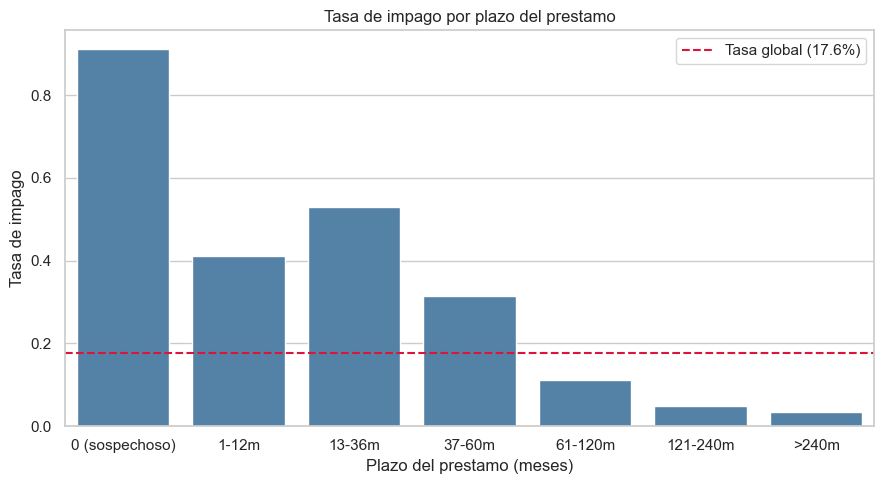

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=tasa_term.index, y=tasa_term["tasa_impago"], ax=ax, color="steelblue")
ax.axhline(tasa_global, color="crimson", linestyle="--", label=f"Tasa global ({tasa_global * 100:.1f}%)")
ax.set_xlabel("Plazo del prestamo (meses)")
ax.set_ylabel("Tasa de impago")
ax.set_title("Tasa de impago por plazo del prestamo")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "default_rate_by_term.png", dpi=150)
plt.show()


### 7.5 Tasa de impago por `NewExist`, `is_franchise`, `RevLineCr`, `LowDoc`, `UrbanRural`


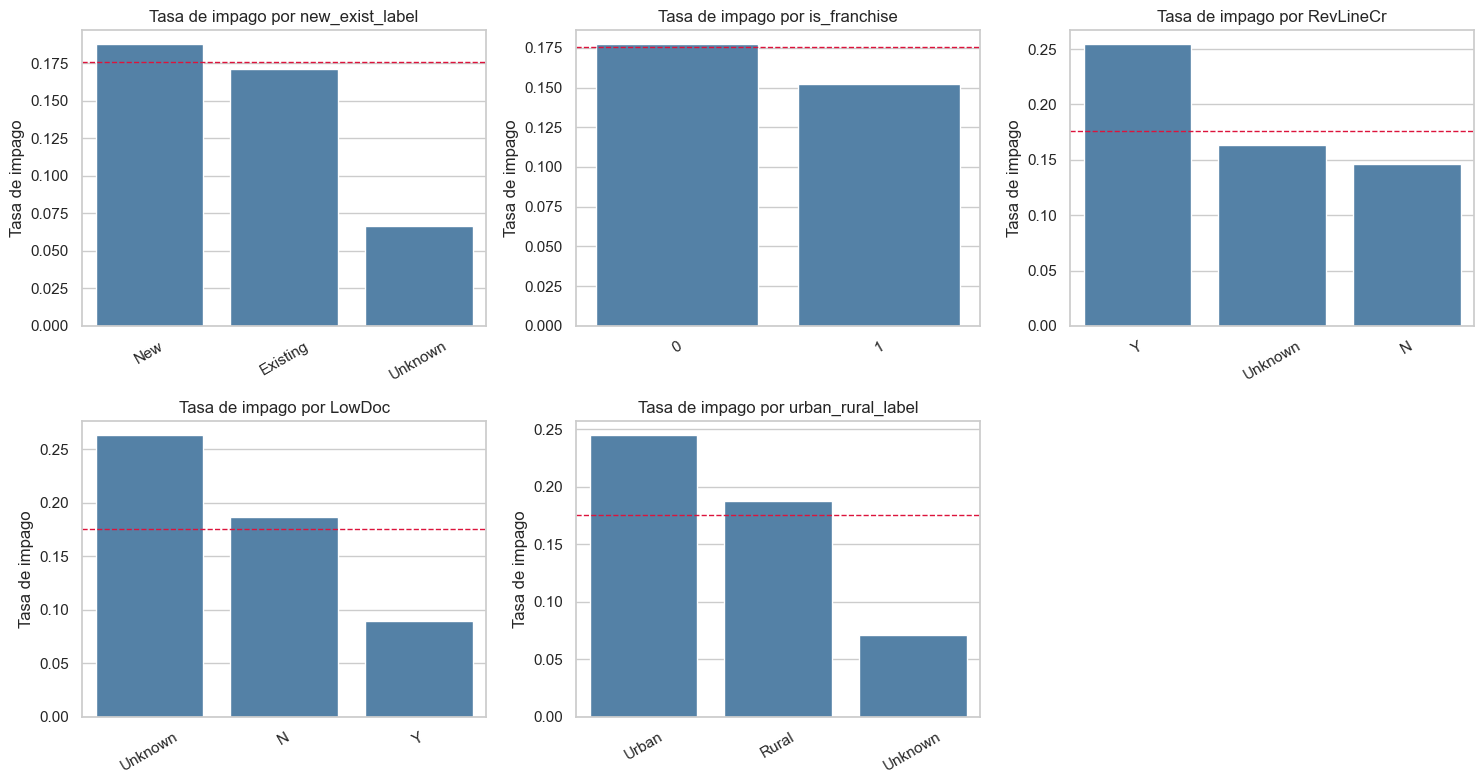

--- new_exist_label ---
                     mean   count
new_exist_label                  
Existing         0.171132  643446
New              0.187548  252559
Unknown          0.066265    1162

--- is_franchise ---
                  mean   count
is_franchise                  
0             0.177066  845435
1             0.151937   51732

--- RevLineCr ---
               mean   count
RevLineCr                  
N          0.146454  419252
Unknown    0.162908  277255
Y          0.254111  200660

--- LowDoc ---
             mean   count
LowDoc                   
N        0.187039  780997
Unknown  0.262877    5999
Y        0.089897  110171

--- urban_rural_label ---


                       mean   count
urban_rural_label                  
Rural              0.187636  105060
Unknown            0.071178  322826
Urban              0.244772  469281



In [38]:
categoricas = ["new_exist_label", "is_franchise", "RevLineCr", "LowDoc", "urban_rural_label"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, categoricas):
    tasa = df.groupby(col, observed=True)["target"].mean().sort_values(ascending=False)
    sns.barplot(x=tasa.index, y=tasa.values, ax=ax, color="steelblue")
    ax.axhline(tasa_global, color="crimson", linestyle="--", linewidth=1)
    ax.set_title(f"Tasa de impago por {col}")
    ax.set_ylabel("Tasa de impago")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
axes[-1].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "default_rate_by_categoricals.png", dpi=150)
plt.show()

for col in categoricas:
    print(f"--- {col} ---")
    print(df.groupby(col, observed=True)["target"].agg(["mean", "count"]))
    print()


### 7.6 Tasa de impago por tramos de `GrAppv` y de `sba_guarantee_pct`

`sba_guarantee_pct = SBA_Appv / GrAppv` es el porcentaje del prestamo
garantizado por la SBA — una de las variables mas citadas en la literatura
sobre este dataset como predictor del impago. La hipotesis habitual es que
a menor garantia de la SBA, mayor "skin in the game" del banco
prestamista y mejor seleccion de riesgo (relacion monotona decreciente).
Comprobamos a continuacion si esa relacion se cumple en los datos.


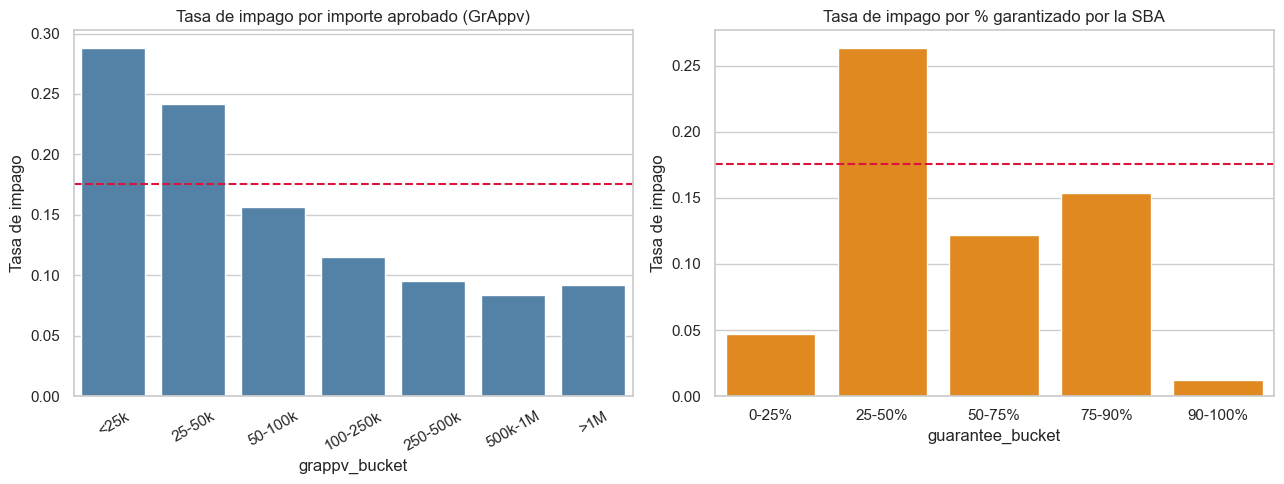

                   mean   count
grappv_bucket                  
<25k           0.288158  179287
25-50k         0.241344  168229
50-100k        0.156676  165201
100-250k       0.114750  185787
250-500k       0.095343  111607
500k-1M        0.083539   66041
>1M            0.092030   21015

                      mean   count
guarantee_bucket                  
0-25%             0.047170     212
25-50%            0.263672  326637
50-75%            0.121844  197400
75-90%            0.154103  301740
90-100%           0.012251   71178


In [39]:
grappv_bins = [0, 25_000, 50_000, 100_000, 250_000, 500_000, 1_000_000, df["GrAppv"].max()]
grappv_labels = ["<25k", "25-50k", "50-100k", "100-250k", "250-500k", "500k-1M", ">1M"]
df["grappv_bucket"] = pd.cut(df["GrAppv"], bins=grappv_bins, labels=grappv_labels)

pct_bins = [0, 0.25, 0.5, 0.75, 0.9, 1.0]
pct_labels = ["0-25%", "25-50%", "50-75%", "75-90%", "90-100%"]
df["guarantee_bucket"] = pd.cut(df["sba_guarantee_pct"], bins=pct_bins, labels=pct_labels, include_lowest=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tasa_grappv = df.groupby("grappv_bucket", observed=True)["target"].mean()
sns.barplot(x=tasa_grappv.index, y=tasa_grappv.values, ax=axes[0], color="steelblue")
axes[0].axhline(tasa_global, color="crimson", linestyle="--")
axes[0].set_title("Tasa de impago por importe aprobado (GrAppv)")
axes[0].set_ylabel("Tasa de impago")
axes[0].tick_params(axis="x", rotation=30)

tasa_pct = df.groupby("guarantee_bucket", observed=True)["target"].mean()
sns.barplot(x=tasa_pct.index, y=tasa_pct.values, ax=axes[1], color="darkorange")
axes[1].axhline(tasa_global, color="crimson", linestyle="--")
axes[1].set_title("Tasa de impago por % garantizado por la SBA")
axes[1].set_ylabel("Tasa de impago")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "default_rate_by_amount_and_guarantee.png", dpi=150)
plt.show()

print(df.groupby("grappv_bucket", observed=True)["target"].agg(["mean", "count"]))
print()
print(df.groupby("guarantee_bucket", observed=True)["target"].agg(["mean", "count"]))


## 8. Distribuciones de las variables numericas principales


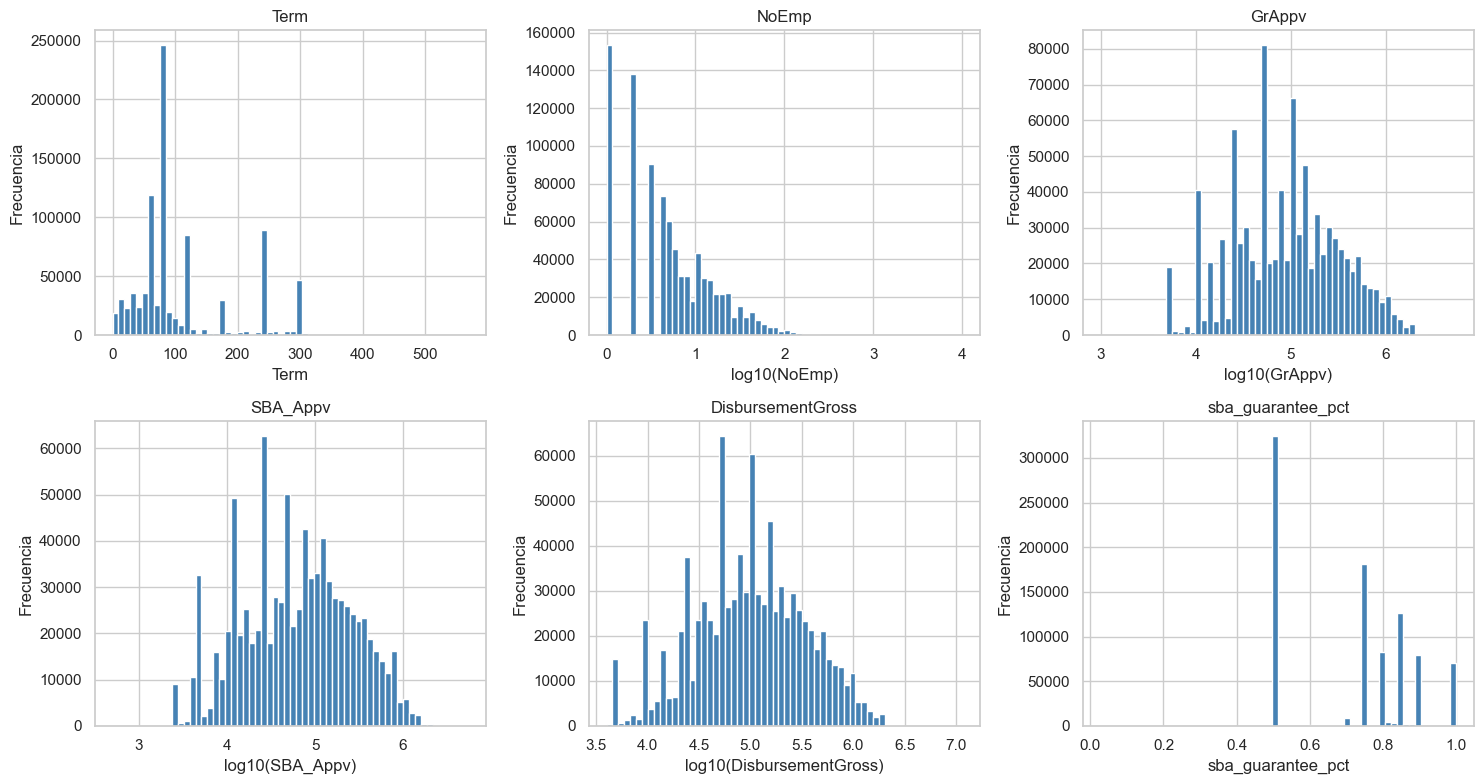

In [40]:
num_cols = ["Term", "NoEmp", "GrAppv", "SBA_Appv", "DisbursementGross", "sba_guarantee_pct"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    data = df[col].dropna()
    use_log = col in {"NoEmp", "GrAppv", "SBA_Appv", "DisbursementGross"}
    if use_log:
        data = data[data > 0]
        ax.hist(np.log10(data), bins=60, color="steelblue")
        ax.set_xlabel(f"log10({col})")
    else:
        ax.hist(data, bins=60, color="steelblue")
        ax.set_xlabel(col)
    ax.set_title(col)
    ax.set_ylabel("Frecuencia")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "distributions_numeric.png", dpi=150)
plt.show()


## 9. Correlaciones entre variables numericas


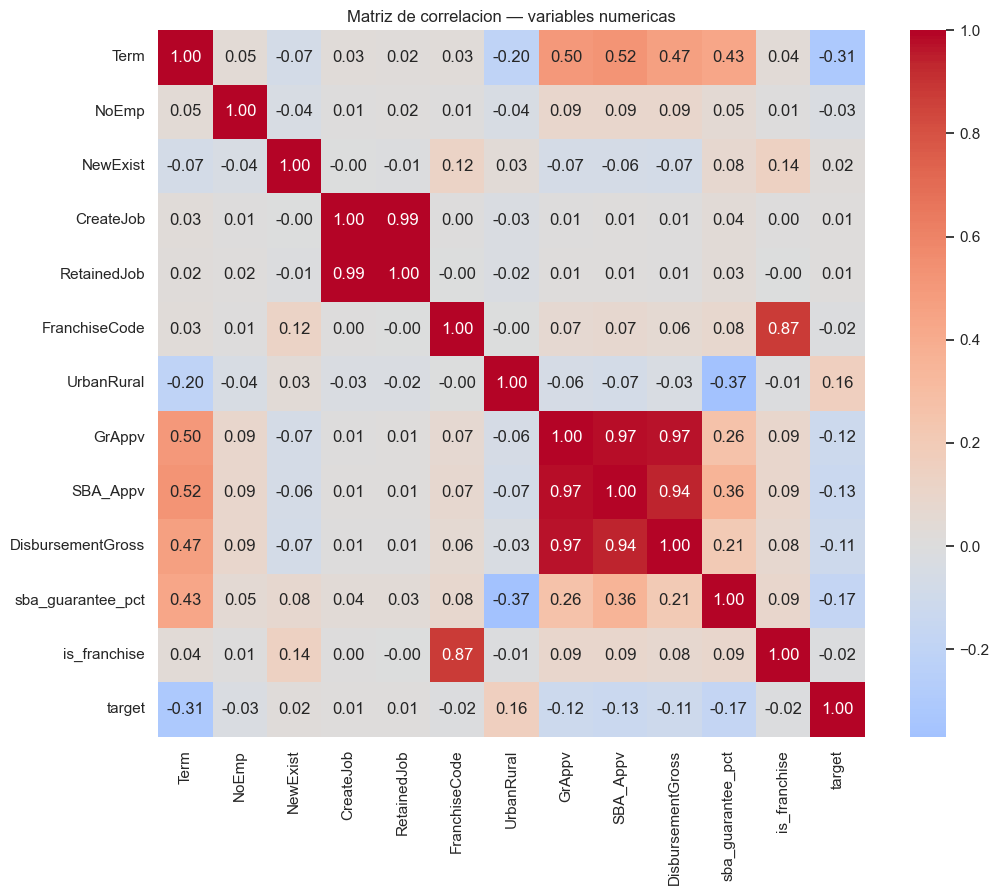

In [41]:
corr_cols = ["Term", "NoEmp", "NewExist", "CreateJob", "RetainedJob", "FranchiseCode",
             "UrbanRural", "GrAppv", "SBA_Appv", "DisbursementGross", "sba_guarantee_pct",
             "is_franchise", "target"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Matriz de correlacion — variables numericas")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=150)
plt.show()


## 10. Conclusiones

- **Calidad de datos**: el dataset crudo tiene multiples columnas con
  codificaciones inconsistentes (`RevLineCr`, `LowDoc`, `NewExist`,
  `NAICS`, `ApprovalFY`) que se han normalizado a categorias explicitas
  (incluyendo `"Unknown"`) sin eliminar filas, preservando el 99.78% del
  dataset original (897.167 de 899.164 filas; solo se eliminan las 1.997
  filas sin `MIS_Status`).
- **El pivote de ano a 2 digitos en las fechas era critico**: usar el
  pivote por defecto (68/69) habria colocado decadas enteras de prestamos
  antiguos (anos 62-68) en el futuro (2062-2068). Se ha verificado que el
  dataset no tiene sufijos de ano entre 15 y 60, lo que permite un pivote
  sin ambiguedad en 14/15, validado ademas con la aserdion de que ninguna
  fecha resultante supera 2014.
- **La tasa de impago global es del 17.56%**, en linea con lo esperado
  (~17.5%), tras eliminar las filas sin target.
- **Cohortes 2005-2008 muestran una tasa de impago claramente superior a
  la media** (hasta 44.6% en 2007, frente al 17.56% global), coincidiendo
  con la crisis financiera de 2008: esto anticipa la necesidad de un marco
  de seguimiento por cohortes (PSI, estabilidad del Gini) en la Fase 3, ya
  que un modelo entrenado sin tener en cuenta el ciclo economico puede
  degradarse fuertemente en cohortes de crisis.
- **La tasa de impago por cohorte esta fuertemente confundida por censura
  y tamano muestral**: las cohortes 1966-1988 (pocas decenas de prestamos)
  muestran tasas cercanas al 100% por sesgo de muestra pequena, y las
  cohortes 2012-2014 muestran tasas artificialmente bajas porque, a fecha
  de corte del dataset (2014), esos prestamos aun no han tenido tiempo de
  hacer default (censura por la derecha). Cualquier analisis de tendencia
  temporal (y el propio split train/test de la Fase 2) debe restringirse
  al rango fiable (~1989-2011) o tratar explicitamente la censura.
- **`sba_guarantee_pct` (SBA_Appv / GrAppv) tiene relacion con el impago,
  pero NO es monotona**: la tasa de impago es minima en el tramo 90-100%
  (1.2%) y en el tramo 0-25% (4.7%, aunque con muy pocas observaciones),
  maxima en 25-50% (26.4%) y intermedia en 50-75%/75-90% (~12-15%). Esto
  contradice la hipotesis simple de "a menor garantia, menor impago" y
  sugiere que el porcentaje garantizado esta actuando como proxy del
  *programa* de prestamo SBA (7(a) estandar, SBA Express, microprestamos,
  etc.), cada uno con su propio perfil de riesgo. Sigue siendo una
  candidata fuerte a feature para la Fase 2, pero probablemente aporte mas
  valor combinada con el importe (`GrAppv`) o modelada de forma no lineal
  que como variable lineal aislada.
- **Existe heterogeneidad relevante por sector y por estado**: algunos
  sectores y estados presentan tasas de impago varios puntos por encima o
  por debajo de la media, lo que sugiere valor en incluir `sector` y
  `State` como features categoricas (vigilando cardinalidad y posible
  necesidad de agrupacion/target encoding en la Fase 2).
- **`Term == 0` y `NoEmp == 0` no son ruido aleatorio**: ambas
  subpoblaciones muestran tasas de impago distintas de la media, por lo
  que se han conservado (con flags de trazabilidad) en lugar de
  eliminarse, evitando perder senal real.
- **Inconsistencia documentada entre `MIS_Status` y `ChgOffDate`**: ~5.2k
  filas tienen `ChgOffDate` informada sin `MIS_Status == CHGOFF` y 47 filas
  al reves. Se ha fijado `MIS_Status` como fuente de verdad del target;
  esta inconsistencia debe tenerse en cuenta si en la Fase 3 se usa
  `ChgOffDate` para reconstruir la evolucion temporal del impago.
- **Riesgo de leakage claramente delimitado**: `ChgOffDate`,
  `ChgOffPrinGr`, `BalanceGross`, `MIS_Status` y (parcialmente)
  `DisbursementDate`/`DisbursementGross` se conocen despues de la
  concesion y quedan excluidas de las features de originacion via
  `LEAKAGE_COLS`, aunque se conservan en el dataset limpio para el
  analisis temporal de la Fase 3.
- **Variables de alta cardinalidad** (`City`, `Bank`, `Zip`) son features
  validas en teoria pero requeriran una estrategia especifica
  (agrupacion, target encoding o exclusion) en la Fase 2 para evitar
  sobreajuste.
- **El dataset limpio queda persistido en
  `data/processed/sba_clean.parquet`**, listo para servir de punto de
  partida unico a las fases 2 (modelado) y 3 (seguimiento), evitando
  repetir la logica de limpieza gracias a `load_and_clean`.
